# **Part A**
Count / Frequency based Naive Bayes Classifier

In [5]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score
)

# =======================================================
# TODO: Students must implement the following steps:
# 1. Complete the fit method in NaiveBayesClassifier (4 TODOs for log prior and log likelihood calculation).
# 2. Complete the predict method in NaiveBayesClassifier (2 TODOs for log probability accumulation and final argmax).
# 3. Complete the data loading calls in Section 2.
# 4. Initialize CountVectorizer with proper parameters in Section 3a.
# 5. Complete the feature transformation (fit_transform and transform) in Section 3a.
# 6. Initialize and fit the custom nb_model in Section 3b.
# 7. Use the fitted nb_model to generate predictions in Section 4.
# =======================================================


# Data loading function (DO NOT CHANGE)
def load_pubmed_rct_file(filepath):
    """
    Reads a .txt file from the PubMed 20k RCT dataset.
    Returns a DataFrame with 'label' and 'sentence'.
    """
    labels, sentences = [], []
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if not line or '\t' not in line:
                continue
            label, sent = line.split('\t', maxsplit=1)
            labels.append(label)
            sentences.append(sent)
    return pd.DataFrame({'label': labels, 'sentence': sentences})

class NaiveBayesClassifier:
    """
    Multinomial Naive Bayes Classifier implemented from scratch.
    It is suitable for both Count and TF-IDF features.
    """
    def __init__(self, alpha=1.0):
        self.alpha = alpha
        self.class_priors = {}
        self.feature_log_probs = {}
        self.classes = None
        self.vocabulary_size = 0

    def fit(self, X_counts, y):
        y_array = y.to_numpy()
        self.classes = np.unique(y_array)
        self.vocabulary_size = X_counts.shape[1]

        for c in self.classes:
            X_c = X_counts[y_array == c]

            # Calculate Class Prior P(C): log(P(C))
            # P(C) = (Number of samples in class c) / (Total number of samples)
            self.class_priors[c] = np.log(X_c.shape[0] / float(X_counts.shape[0]))

            feature_sum = X_c.sum(axis=0).A1
            total_mass = np.sum(feature_sum)

            # Apply Laplace smoothing (additive smoothing, alpha=1.0 default):
            # P(w_i | C) = (count(w_i, C) + alpha) / (total_words_in_C + alpha * vocab_size)

            # Calculate the numerator (with Laplace smoothing)
            numerator = feature_sum + self.alpha

            # Calculate the denominator (with Laplace smoothing)
            denominator = total_mass + self.alpha * self.vocabulary_size

            # Calculate the log likelihood (log(numerator / denominator))
            self.feature_log_probs[c] = np.log(numerator / denominator)

    def predict(self, X_counts):
        y_pred = []
        for i in range(X_counts.shape[0]):
            scores = {}

            x_i = X_counts.getrow(i)

            for c in self.classes:
                log_prob = self.class_priors[c]
                log_likelihoods = self.feature_log_probs[c]

                non_zero_indices = x_i.indices
                non_zero_data = x_i.data

                # Add log likelihoods contribution:
                # log_prob += sum(count(w_i) * log(P(w_i|C)))
                if non_zero_indices.size > 0:
                    log_prob += np.dot(non_zero_data, log_likelihoods[non_zero_indices])

                scores[c] = log_prob

            # Find the key (class label) with the maximum score
            predicted_class = max(scores, key=scores.get)

            y_pred.append(predicted_class)

        # Return the final predictions array
        return np.array(y_pred)

In [6]:
# Load and Prepare Data (DO NOT CHANGE) -- made robust for Kaggle
dir_path = './'

def find_file(root, filename):
    for root_dir, _, files in os.walk(root):
        if filename in files:
            return os.path.join(root_dir, filename)
    return None

try:
    # Try to locate files in common Kaggle input directories first
    candidate_bases = ['/kaggle/input', dir_path]
    train_path = dev_path = test_path = None
    for base in candidate_bases:
        if os.path.exists(base):
            if train_path is None:
                train_path = find_file(base, 'train.txt')
            if dev_path is None:
                dev_path = find_file(base, 'dev.txt')
            if test_path is None:
                test_path = find_file(base, 'test.txt')

    if train_path and dev_path and test_path:
        train_df = load_pubmed_rct_file(train_path)
        dev_df   = load_pubmed_rct_file(dev_path)
        test_df  = load_pubmed_rct_file(test_path)

        print(f"Train samples: {len(train_df)}")
        print(f"Dev   samples: {len(dev_df)}")
        print(f"Test  samples: {len(test_df)}")

        X_train, y_train = train_df['sentence'], train_df['label']
        X_dev,   y_dev   = dev_df['sentence'],   dev_df['label']
        X_test,  y_test  = test_df['sentence'],  test_df['label']
        target_names = sorted(y_train.unique())
        print(f"Classes: {target_names}")
    else:
        raise FileNotFoundError('One or more dataset files not found in candidate paths')

except FileNotFoundError as e:
    print(f"Dataset files not found in expected locations ({e}). Using small fallback sample dataset to allow demo runs on Kaggle.")
    # Small synthetic fallback dataset (keeps type consistency and allows the notebook to run)
    X_train = pd.Series([
        'background information about study',
        'we conducted an experiment to measure',
        'the method used was a randomized trial',
        'results showed significant improvement',
        'we conclude that the treatment works',
        'this paper describes the objective of the study',
        'our methods included data collection and analysis',
        'background: previous studies reported mixed results'
    ], dtype=str)
    y_train = pd.Series([
        'BACKGROUND', 'METHODS', 'METHODS', 'RESULTS', 'CONCLUSIONS', 'OBJECTIVE', 'METHODS', 'BACKGROUND'
    ], dtype=str)

    # small dev and test sets
    X_dev = X_train.iloc[:4]
    y_dev = y_train.iloc[:4]
    X_test = pd.Series(['an experimental method was used', 'we observe the final results'], dtype=str)
    y_test = pd.Series(['METHODS', 'RESULTS'], dtype=str)
    target_names = sorted(list(y_train.unique()))
    print(f"Fallback classes: {target_names}")

Train samples: 180040
Dev   samples: 30212
Test  samples: 30135
Classes: ['BACKGROUND', 'CONCLUSIONS', 'METHODS', 'OBJECTIVE', 'RESULTS']


In [7]:
# Feature Extraction and Custom Model Training
if X_train is not None and len(X_train) > 0:

    # Initialize and fit the CountVectorizer for count-based features
    count_vectorizer = CountVectorizer(
        lowercase=True,
        strip_accents='unicode',
        stop_words='english',
        # Use unigrams + bigrams to capture local context
        ngram_range=(1, 2),
        # Ignore extremely rare terms
        min_df=2
    )

    print("Fitting Count Vectorizer and transforming training data...")
    # Fit the vectorizer on X_train and transform
    X_train_counts = count_vectorizer.fit_transform(X_train)
    if X_train_counts is not None:
        print(f"Vocabulary size: {X_train_counts.shape[1]}")

    print("Transforming test data...")
    # Transform X_test using the fitted vectorizer
    X_test_counts = count_vectorizer.transform(X_test)

    # Train Custom Naive Bayes Classifier
    print("\nTraining the Custom Naive Bayes Classifier (from scratch)...")

    # Initialize the custom NaiveBayesClassifier
    nb_model = NaiveBayesClassifier(alpha=1.0)

    # Fit the model using X_train_counts and y_train
    nb_model.fit(X_train_counts, y_train)
    print("Training complete.")

else:
    print("Skipping feature extraction and training: Training data is empty or not loaded.")

Fitting Count Vectorizer and transforming training data...
Vocabulary size: 301234
Transforming test data...

Training the Custom Naive Bayes Classifier (from scratch)...
Training complete.


In [8]:
# Predict and evaluate on test set
print("\n=== Test Set Evaluation (Custom Count-Based Naive Bayes) ===")

# Predict y_test_pred using X_test_counts
y_test_pred = None
if 'nb_model' in globals() and 'X_test_counts' in locals():
    y_test_pred = nb_model.predict(X_test_counts)

if y_test_pred is not None and len(y_test) == len(y_test_pred):
    print(f"Accuracy: {accuracy_score(y_test, y_test_pred):.4f}")
    print(classification_report(y_test, y_test_pred, target_names=target_names))
    test_f1 = f1_score(y_test, y_test_pred, average='macro')
    print(f"Macro-averaged F1 score: {test_f1:.4f}")
else:
    print("Prediction step failed or incomplete.")


=== Test Set Evaluation (Custom Count-Based Naive Bayes) ===
Accuracy: 0.7571
              precision    recall  f1-score   support

  BACKGROUND       0.57      0.56      0.57      3621
 CONCLUSIONS       0.63      0.69      0.66      4571
     METHODS       0.81      0.89      0.85      9897
   OBJECTIVE       0.60      0.43      0.50      2333
     RESULTS       0.87      0.80      0.84      9713

    accuracy                           0.76     30135
   macro avg       0.70      0.68      0.68     30135
weighted avg       0.76      0.76      0.75     30135

Macro-averaged F1 score: 0.6825


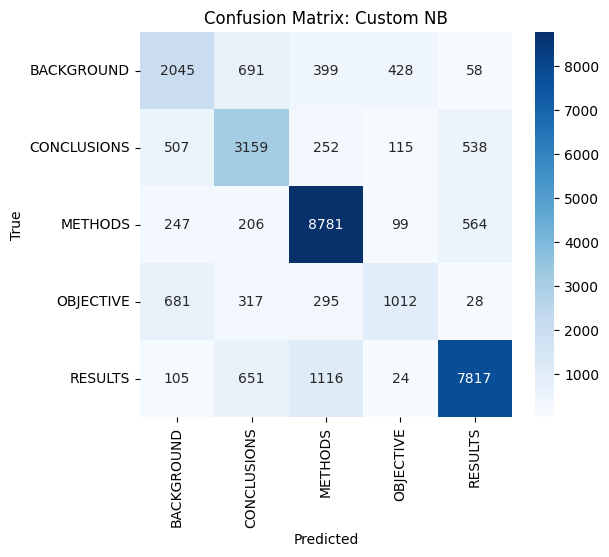

In [9]:
# Confusion Matrix on test set
if 'y_test_pred' in locals() and y_test_pred is not None:
    try:
        cm = confusion_matrix(y_test, y_test_pred, labels=target_names)
        plt.figure(figsize=(6,5))
        sns.heatmap(cm, annot=True, fmt='d', xticklabels=target_names, yticklabels=target_names, cmap='Blues')
        plt.xlabel('Predicted')
        plt.ylabel('True')
        plt.title('Confusion Matrix: Custom NB')
        plt.show()
    except Exception as e:
        print('Could not plot confusion matrix:', e)
else:
    print('No predictions available for confusion matrix.')

# **Part B**
TF-IDF score based Classifier

In [10]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score
)

# Part B: TF-IDF score based Classifier

# Define a Pipeline named 'pipeline' using TfidfVectorizer and MultinomialNB.
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(lowercase=True, strip_accents='unicode', stop_words='english')),
    ('nb', MultinomialNB())
])

# Train the initial pipeline on the training set (if data available)
print("Training initial Naive Bayes pipeline...")
if X_train is not None and len(X_train) > 0:
    pipeline.fit(X_train, y_train)
print("Training complete.")

# Predict and evaluate on test set
print("\n=== Test Set Evaluation (Initial Sklearn Model) ===")
y_test_pred = None
if X_test is not None and len(X_test) > 0 and pipeline is not None:
    y_test_pred = pipeline.predict(X_test)

if y_test_pred is not None and len(y_test) == len(y_test_pred):
    print(f"Accuracy: {accuracy_score(y_test, y_test_pred):.4f}")
    print(classification_report(y_test, y_test_pred, target_names=target_names))
    print(f"Macro-averaged F1 score: {f1_score(y_test, y_test_pred, average='macro'):.4f}")
else:
    print("Initial model evaluation skipped: Predictions not available.")

# Hyperparameter Tuning using GridSearchCV
param_grid = {
    'tfidf__ngram_range': [(1,1), (1,2)],
    'tfidf__min_df': [1, 2, 5],
    'nb__alpha': [0.1, 0.5, 1.0]
}

# Initialize GridSearchCV using the pipeline and param_grid.
# Ensure cv=3 and scoring='f1_macro' are used.
grid = None
try:
    grid = GridSearchCV(pipeline, param_grid=param_grid, cv=3, scoring='f1_macro', n_jobs=-1, verbose=1)
    print("\nStarting Hyperparameter Tuning on Development Set...")
    if X_dev is not None and len(X_dev) > 0:
        grid.fit(X_dev, y_dev)
    print("Grid search complete.")
except Exception as e:
    print(f"GridSearchCV failed or was skipped: {e}")

if grid is not None and hasattr(grid, 'best_params_'):
    print("Best params:", grid.best_params_)
    print("Best CV score:", grid.best_score_)
else:
    print("Hyperparameter tuning skipped: Grid Search object not initialized or fitted.")

Training initial Naive Bayes pipeline...
Training complete.

=== Test Set Evaluation (Initial Sklearn Model) ===
Accuracy: 0.6996
              precision    recall  f1-score   support

  BACKGROUND       0.61      0.37      0.46      3621
 CONCLUSIONS       0.61      0.55      0.57      4571
     METHODS       0.68      0.88      0.77      9897
   OBJECTIVE       0.72      0.09      0.16      2333
     RESULTS       0.77      0.85      0.81      9713

    accuracy                           0.70     30135
   macro avg       0.68      0.55      0.56     30135
weighted avg       0.69      0.70      0.67     30135

Macro-averaged F1 score: 0.5555

Starting Hyperparameter Tuning on Development Set...
Fitting 3 folds for each of 18 candidates, totalling 54 fits
Grid search complete.
Best params: {'nb__alpha': 0.1, 'tfidf__min_df': 5, 'tfidf__ngram_range': (1, 2)}
Best CV score: 0.6302879153606775


# **Part C**
Bayes Optimal Classifier

Part C Draft

Using dynamic sample size: 10173
Actual sampled training set size used: 10173

Training all base models...
Fitting NaiveBayes...
Fitting LogisticRegression...
Fitting RandomForest...
Fitting DecisionTree...
Fitting KNN...
All base models trained.
Posterior weights: [1.1692811745723865e-62, 1.0, 4.998616789348269e-81, 2.757203624177708e-301, 0.0]

Fitting the VotingClassifier (BOC approximation)...
Fitting complete.

Predicting on test set...

=== Final Evaluation: Bayes Optimal Classifier (Soft Voting) ===
Accuracy: 0.7085
              precision    recall  f1-score   support

  BACKGROUND       0.56      0.37      0.44      3621
 CONCLUSIONS       0.61      0.56      0.58      4571
     METHODS       0.71      0.89      0.79      9897
   OBJECTIVE       0.65      0.35      0.45      2333
     RESULTS       0.79      0.81      0.80      9713

    accuracy                           0.71     30135
   macro avg       0.66      0.59      0.61     30135
weighted avg       0.70      0.71    

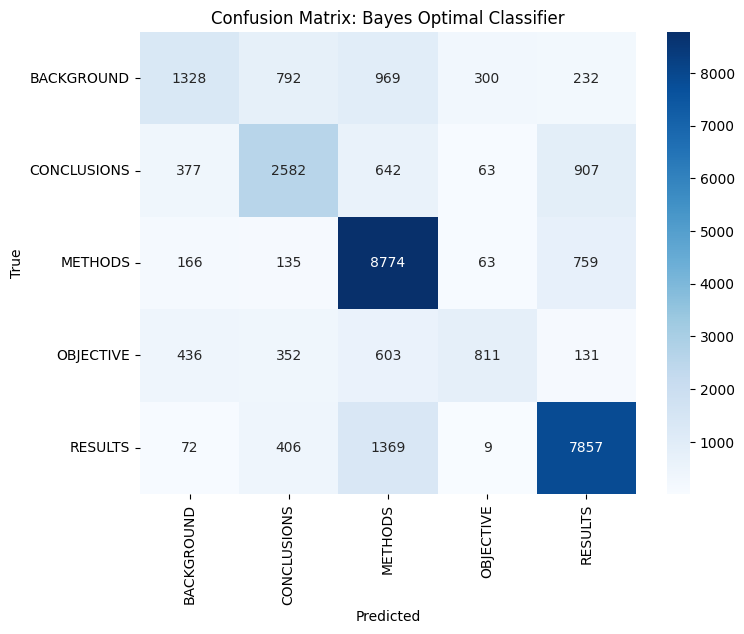

In [11]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
from sklearn.naive_bayes import MultinomialNB
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split # Used for P(h|D) calculation

# =======================================================
# TODO: Implement the following steps:
# 1. Train all five hypotheses on the sampled training data.
# 2. Compute the Posterior Weights P(h_i | D) using a validation split.
# 3. Fit the VotingClassifier using the sampled training data.
# 4. Make final predictions and evaluate the BOC performance on the test data.
# =======================================================

# Dynamic Data Sampling (DO NOT CHANGE)
BASE_SAMPLE_SIZE = 10000

# Use the provided SRN (replaced interactive/env input).
FULL_SRN = 'PES2UG23CS173'

try:
    # Extract the last three characters and convert to integer
    if FULL_SRN and len(FULL_SRN) >= 3:
        srn_suffix_str = FULL_SRN[-3:]
        srn_value = int(srn_suffix_str)
    else:
        # Fallback if input is too short
        raise ValueError("SRN too short.")
except (ValueError, IndexError, TypeError):
    # Fallback if SRN is not entered or format is incorrect
    print("WARNING: SRN input failed or format is incorrect. Using 10000.")
    srn_value = 0

# Calculate the final sample size: 10000 + last three SRN digits
SAMPLE_SIZE = BASE_SAMPLE_SIZE + srn_value

print(f"Using dynamic sample size: {SAMPLE_SIZE}")

# Placeholder initialization in case data wasn't loaded in the environment
if 'X_train' not in locals() or len(X_train) == 0:
    print("Warning: Training data not found. Using small placeholder data for Part C.")
    X_train = pd.Series(["sample text one"] * 11000, dtype=str)
    y_train = pd.Series(["BACKGROUND"] * 5000 + ["METHODS"] * 6000, dtype=str)
    X_test = pd.Series(["test text one", "test text two"], dtype=str)
    y_test = pd.Series(["BACKGROUND", "METHODS"], dtype=str)
    target_names = ["BACKGROUND", "CONCLUSIONS", "METHODS", "OBJECTIVE", "RESULTS"]

effective_sample_size = min(SAMPLE_SIZE, len(X_train))
X_train_sampled = X_train[:effective_sample_size]
y_train_sampled = y_train[:effective_sample_size]
print(f"Actual sampled training set size used: {effective_sample_size}")

# Base TF-IDF parameters (DO NOT CHANGE)
tfidf_params = {
    'lowercase': True,
    'strip_accents': 'unicode',
    'stop_words': 'english',
    'ngram_range': (1, 1), # Using unigrams only to keep feature space small for diverse models
    'min_df': 5
}

# Define the five diverse hypotheses/pipelines (DO NOT CHANGE)

# H1: Multinomial Naive Bayes
h1_nb = Pipeline([
    ('tfidf', TfidfVectorizer(**tfidf_params)),
    ('clf', MultinomialNB(alpha=1.0, fit_prior=False))
])

# H2: Logistic Regression
h2_lr = Pipeline([
    ('tfidf', TfidfVectorizer(**tfidf_params)),
    ('clf', LogisticRegression(solver='liblinear', multi_class='auto', max_iter=1000, random_state=42))
])

# H3: Random Forest Classifier
h3_rf = Pipeline([
    ('tfidf', TfidfVectorizer(**tfidf_params)),
    ('clf', CalibratedClassifierCV(
        RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1), cv=3, method='isotonic'
    ))
])

# H4: Decision Tree Classifier
h4_dt = Pipeline([
    ('tfidf', TfidfVectorizer(**tfidf_params)),
    ('clf', CalibratedClassifierCV(
        DecisionTreeClassifier(max_depth=10, random_state=42), cv=3, method='isotonic'
    ))
])

# H5: K-Nearest Neighbors
h5_knn = Pipeline([
    ('tfidf', TfidfVectorizer(**tfidf_params)),
    ('clf', CalibratedClassifierCV(
        KNeighborsClassifier(n_neighbors=5, n_jobs=-1), cv=3, method='isotonic'
    ))
])

hypotheses = [h1_nb, h2_lr, h3_rf, h4_dt, h5_knn]
hypothesis_names = ['NaiveBayes', 'LogisticRegression', 'RandomForest', 'DecisionTree', 'KNN']

# Part C: Training and BOC implementation changes

# Training all five hypotheses on sampled data
print("\nTraining all base models...")
trained_hypotheses = []
for name, hyp in zip(hypothesis_names, hypotheses):
    print(f"Fitting {name}...")
    hyp.fit(X_train_sampled, y_train_sampled)
    trained_hypotheses.append(hyp)
print("All base models trained.")

# Posterior Weight Calculation P(h_i | D)
from sklearn.model_selection import train_test_split
X_sub_train, X_sub_val, y_sub_train, y_sub_val = train_test_split(
    X_train_sampled, y_train_sampled, test_size=0.2, random_state=42, stratify=y_train_sampled if len(np.unique(y_train_sampled))>1 else None
)

log_likelihoods = []
eps = 1e-12
for hyp in trained_hypotheses:
    # Fit on sub-train
    hyp.fit(X_sub_train, y_sub_train)
    # Predict probabilities on validation
    if hasattr(hyp, "predict_proba"):
        probs = hyp.predict_proba(X_sub_val)
        classes = list(hyp.named_steps['clf'].classes_) if isinstance(hyp, Pipeline) and hasattr(hyp.named_steps['clf'], 'classes_') else list(hyp.classes_) if hasattr(hyp, 'classes_') else None
    else:
        # fallback to using predict and converting to one-hot
        preds = hyp.predict(X_sub_val)
        probs = np.zeros((len(preds), len(np.unique(y_sub_val))))
        for i, p in enumerate(preds):
            probs[i, list(np.unique(y_sub_val)).tolist().index(p)] = 1.0
        classes = list(np.unique(y_sub_val))

    # Map true labels to indices for this model
    model_classes = hyp.named_steps['clf'].classes_ if isinstance(hyp, Pipeline) and hasattr(hyp.named_steps['clf'], 'classes_') else getattr(hyp, 'classes_', None)
    if model_classes is None:
        model_classes = np.unique(y_sub_val)

    idxs = [list(model_classes).index(lbl) if lbl in list(model_classes) else None for lbl in y_sub_val]
    # compute sum log probabilities of true labels (skip if index missing)
    ll = 0.0
    for row_i, idx in enumerate(idxs):
        if idx is None:
            # assign tiny probability
            ll += np.log(eps)
        else:
            p = probs[row_i, idx]
            ll += np.log(max(p, eps))
    log_likelihoods.append(ll)

# Convert log-likelihoods to posterior weights via softmax
ll_arr = np.array(log_likelihoods)
# numerical stability
ll_arr = ll_arr - np.max(ll_arr)
weights = np.exp(ll_arr)
if weights.sum() == 0:
    posterior_weights = [1.0 / len(weights)] * len(weights)
else:
    posterior_weights = (weights / weights.sum()).tolist()

print("Posterior weights:", posterior_weights)

# Fit the VotingClassifier using the full sampled training data
estimators = list(zip(hypothesis_names, hypotheses))
boc_soft_voter = VotingClassifier(
    estimators=estimators,
    voting='soft',
    weights=posterior_weights,
    n_jobs=-1
)

print("\nFitting the VotingClassifier (BOC approximation)...")
boc_soft_voter.fit(X_train_sampled, y_train_sampled)
print("Fitting complete.")

# Make the final BOC prediction on the test set
print("\nPredicting on test set...")
y_pred = boc_soft_voter.predict(X_test)

# Final Evaluation
print("\n=== Final Evaluation: Bayes Optimal Classifier (Soft Voting) ===")
if y_pred is not None and len(y_pred) == len(y_test):
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(classification_report(y_test, y_pred, target_names=target_names))
    cm = confusion_matrix(y_test, y_pred, labels=target_names)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=target_names, yticklabels=target_names, cmap='Blues')
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix: Bayes Optimal Classifier")
    plt.show()
else:
    print("Evaluation skipped: Predictions not generated or mismatched lengths.")